# Importation des données (pour tester la lecture des données)

In [1]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_csv("weather_prediction_dataset.csv")

# Conversion date
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")

# Ajout features temporelles
df["dayofyear"] = df["DATE"].dt.dayofyear
df["sin_day"] = np.sin(2*np.pi*df["dayofyear"]/365)
df["cos_day"] = np.cos(2*np.pi*df["dayofyear"]/365)

# Exemple : forecasting BASEL_temp_mean à J+1
target = "BASEL_temp_mean"
horizon = 1  # 1 jour dans le futur

# Décalage de la cible
df[f"{target}_future"] = df[target].shift(-horizon)

# Lags pour capture de la dynamique
for lag in [1, 2, 3, 7]:
    df[f"{target}_lag{lag}"] = df[target].shift(lag)

# Moyennes glissantes
df[f"{target}_roll3"] = df[target].shift(1).rolling(3).mean()
df[f"{target}_roll7"] = df[target].shift(1).rolling(7).mean()

# Nettoyage
df = df.dropna()

# Séparation features / labels
X = df.drop(columns=[target, f"{target}_future"])
y = df[f"{target}_future"]

print(X.head())
print(y.head())


         DATE  MONTH  BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  \
7  2000-01-08      1                  4            0.79          1.0248   
8  2000-01-09      1                  8            0.88          1.0243   
9  2000-01-10      1                  8            0.91          1.0337   
10 2000-01-11      1                  8            0.88          1.0373   
11 2000-01-12      1                  8            0.77          1.0319   

    BASEL_global_radiation  BASEL_precipitation  BASEL_sunshine  \
7                     0.54                 0.00             4.3   
8                     0.11                 0.65             0.0   
9                     0.06                 0.09             0.0   
10                    0.06                 0.00             0.0   
11                    0.10                 0.00             0.0   

    BASEL_temp_min  BASEL_temp_max  ...  TOURS_temp_max  dayofyear   sin_day  \
7              4.1             8.4  ...            11.0          8

# Importation des différentes librairies

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## Première Tentative Avec un LSTM multivariate

In [6]:
# --- Dataset pour séquences temporelles ---
class WeatherDataset(Dataset):
    def __init__(self, df, target_col, seq_len=14, horizon=1, split="train", test_size=20):
        self.seq_len = seq_len
        self.horizon = horizon

        # Normalisation min-max
        self.data = (df - df.min()) / (df.max() - df.min() + 1e-8)
        self.values = self.data.values.astype(np.float32)

        self.target_idx = df.columns.get_loc(target_col)

        # Indices train/test
        split_idx = len(self.values) - test_size
        if split == "train":
            self.start, self.end = 0, split_idx
        else:
            self.start, self.end = split_idx - seq_len - horizon, len(self.values)

    def __len__(self):
        return self.end - self.start - self.seq_len - self.horizon

    def __getitem__(self, idx):
        i = self.start + idx
        x = self.values[i : i + self.seq_len]
        y = self.values[i + self.seq_len + self.horizon - 1, self.target_idx]
        return torch.tensor(x), torch.tensor(y)


# --- Modèle LSTM multivariate ---
class LSTMForecast(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze()


# --- Entrainement ---
def train_lstm_model(train_loader, hidden_dim=64, num_layers=2, epochs=20, lr=1e-3):
    # Initialiser modèle
    model = LSTMForecast(input_dim=df.shape[1], hidden_dim=hidden_dim, num_layers=num_layers)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Entraînement
    for epoch in range(epochs):
        losses = []
        for X, y in train_loader:
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        print(f"Epoch {epoch+1}/{epochs}, Loss={np.mean(losses):.4f}")

    return model

# Entrainement du model

In [7]:
# Charger et préparer les données
df = pd.read_csv("weather_prediction_dataset.csv")
df["DATE"] = pd.to_datetime(df["DATE"], format="%Y%m%d")
df = df.drop(columns=["DATE", "MONTH"])  # garder uniquement variables numériques
df = df.dropna()


# Split train/testtarget_col="BASEL_temp_mean"
target_col="BASEL_temp_mean"
seq_len=14
horizon=1
batch_size=32
test_size=14
train_dataset = WeatherDataset(df, target_col, seq_len, horizon, split="train", test_size=test_size)
test_dataset  = WeatherDataset(df, target_col, seq_len, horizon, split="test", test_size=test_size)
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size, shuffle=False)

model = train_lstm_model(train_loader)

Epoch 1/20, Loss=0.0161
Epoch 2/20, Loss=0.0039
Epoch 3/20, Loss=0.0032
Epoch 4/20, Loss=0.0026
Epoch 5/20, Loss=0.0022
Epoch 6/20, Loss=0.0020
Epoch 7/20, Loss=0.0019
Epoch 8/20, Loss=0.0019
Epoch 9/20, Loss=0.0018
Epoch 10/20, Loss=0.0017
Epoch 11/20, Loss=0.0017
Epoch 12/20, Loss=0.0019
Epoch 13/20, Loss=0.0017
Epoch 14/20, Loss=0.0017
Epoch 15/20, Loss=0.0016
Epoch 16/20, Loss=0.0016
Epoch 17/20, Loss=0.0016
Epoch 18/20, Loss=0.0015
Epoch 19/20, Loss=0.0015
Epoch 20/20, Loss=0.0015


# Test de la prédiction

Coefficient de corrélation : 0.8179
p-value : 3.5111e-04


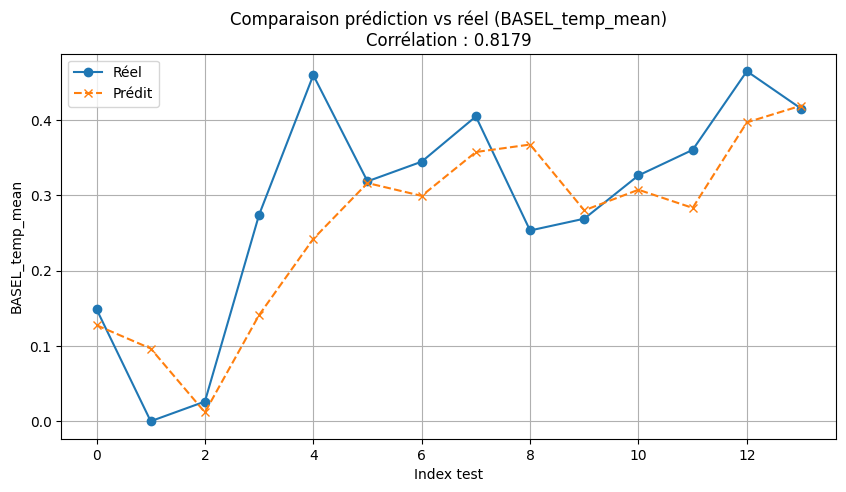

In [13]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Supposons que preds et reals sont déjà des listes aplaties comme avant
preds_array = np.array(preds)
reals_array = np.array(reals)

# Coefficient de corrélation de Pearson
corr_coef, p_value = pearsonr(reals_array, preds_array)
print(f"Coefficient de corrélation : {corr_coef:.4f}")
print(f"p-value : {p_value:.4e}")

# Graphique pour visualiser
plt.figure(figsize=(10,5))
plt.plot(range(len(reals_array)), reals_array, label="Réel", marker="o")
plt.plot(range(len(preds_array)), preds_array, label="Prédit", marker="x", linestyle="--")
plt.title(f"Comparaison prédiction vs réel ({target_col})\nCorrélation : {corr_coef:.4f}")
plt.xlabel("Index test")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()
